In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from google.colab import files

uploaded = files.upload()

Saving student_marks.csv to student_marks.csv


In [4]:
df = pd.read_csv('student_marks.csv')

In [5]:
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [6]:
df.shape

(200, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [11]:
df.describe()


,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


Text(0.5, 1.0, 'study_hours vs student_marks')

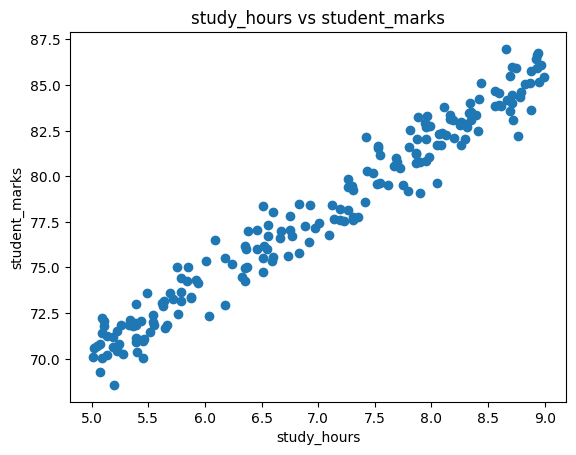

In [14]:
plt.scatter(df.study_hours,df.student_marks)
plt.xlabel('study_hours')
plt.ylabel('student_marks')
plt.title('study_hours vs student_marks')

In [15]:
df.isnull().sum()

,0
study_hours,5
student_marks,0


In [16]:
df.study_hours.mean()

np.float64(6.9959487179487185)

In [18]:
df2=df.fillna(df.study_hours.mean())

In [20]:
df2.isnull().sum()

,0
study_hours,0
student_marks,0


In [21]:
x=df2.study_hours
y=df2.student_marks

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [23]:
x_train

,study_hours
108,5.84
107,5.72
189,7.26
14,8.19
56,5.75
...,...
133,5.76
137,5.14
72,6.35
140,8.60


In [24]:
y_train

,student_marks
108,74.25
107,73.25
189,79.87
14,83.08
56,75.03
...,...
133,72.46
137,71.22
72,74.97
140,84.58


In [25]:
x_test

,study_hours
58,5.390000
40,5.280000
34,8.720000
102,8.260000
184,5.220000
198,6.600000
95,6.090000
4,8.670000
29,7.480000
168,7.950000


In [26]:
y_test

,student_marks
58,70.90
40,70.27
34,83.08
102,82.99
184,71.50
198,78.05
95,76.48
4,84.19
29,80.17
168,82.68


In [31]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train.to_frame(), y_train)

LinearRegression()

In [32]:
lr.coef_

array([3.91952524])

In [33]:
lr.intercept_

np.float64(50.58222738856022)

In [34]:
lr.predict([[40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([207.36323699])

In [38]:
y_pred=lr.predict(x_test.to_frame())
y_pred

array([71.70846843, 71.27732066, 84.76048748, 82.95750587, 71.04214914,
       76.45109397, 74.4521361 , 84.56451122, 79.90027618, 81.74245305,
       78.76361387, 83.54543466, 84.13336344, 85.03485425, 81.86003881,
       72.88432601, 81.38969578, 78.41085659, 82.56555335, 72.727545  ,
       79.23395689, 75.51040792, 82.29118658, 80.72337649, 78.00302497,
       81.11532901, 72.60995924, 73.86420732, 80.17464295, 76.96063225,
       70.21904884, 71.66927318, 75.47121266, 73.27627853, 85.58358778,
       70.96375864, 71.70846843, 79.62590942, 82.91831062, 79.3907379 ])

In [39]:
pd.DataFrame(np.c_[x_test,y_test,y_pred],columns=['study_hours','student_marks','predicted_marks'])

,study_hours,student_marks,predicted_marks
0,5.390000,70.90,71.708468
1,5.280000,70.27,71.277321
2,8.720000,83.08,84.760487
3,8.260000,82.99,82.957506
4,5.220000,71.50,71.042149
5,6.600000,78.05,76.451094
6,6.090000,76.48,74.452136
7,8.670000,84.19,84.564511
8,7.480000,80.17,79.900276
9,7.950000,82.68,81.742453


In [41]:
lr.score(x_test.to_frame(),y_test)

0.948241670182336

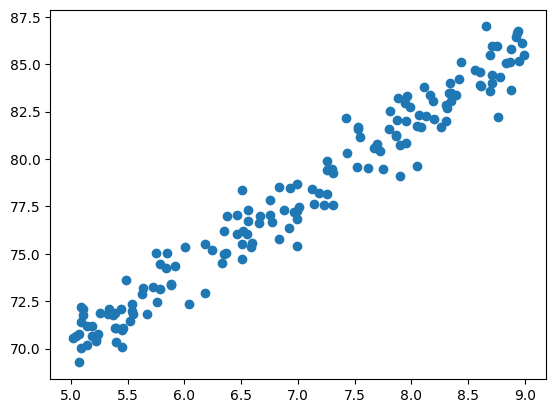

In [46]:
plt.scatter(x_train,y_train)

In [47]:
lr.predict(x_train.to_frame())

array([73.47225479, 73.00191176, 79.03798063, 82.68313911, 73.11949752,
       80.64498598, 78.4892471 , 81.46808628, 82.13440557, 84.64290173,
       85.38761152, 80.44900972, 76.45109397, 72.21800671, 84.995659  ,
       79.03798063, 72.33559247, 71.51249217, 83.31026314, 84.72129223,
       71.74766369, 82.95750587, 70.53261086, 71.9828352 , 83.66302042,
       80.17464295, 78.5676376 , 75.90236044, 72.29639722, 81.38969578,
       84.91726849, 77.54856104, 84.32933971, 80.09625245, 81.15452426,
       81.74245305, 80.958548  , 85.19163526, 81.54647679, 76.13753195,
       77.7445373 , 80.05705719, 81.7032578 , 78.00302497, 71.04214914,
       81.54647679, 76.68626549, 77.35258478, 72.29639722, 74.80489337,
       82.21279608, 81.38969578, 79.19476164, 85.34841627, 71.12053965,
       79.23395689, 80.09625245, 85.62278304, 83.11428688, 71.04214914,
       74.25615984, 82.56555335, 82.72233436, 82.25199133, 78.00302497,
       71.63007793, 72.64915449, 71.70846843, 76.72546074, 77.70

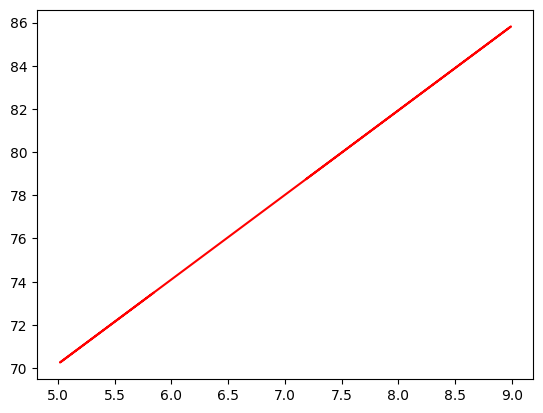

In [49]:
plt.plot(x_train, lr.predict(x_train.to_frame()), 'r-')

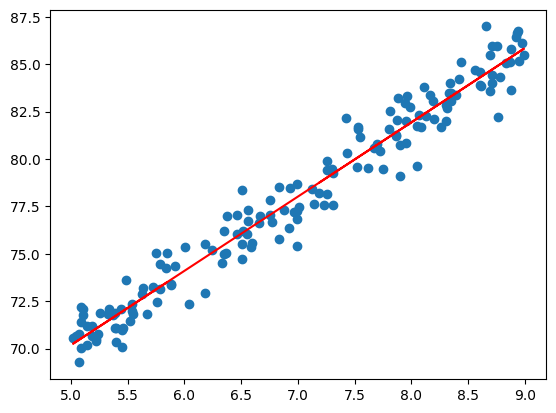

In [50]:
plt.scatter(x_train,y_train)
plt.plot(x_train, lr.predict(x_train.to_frame()), 'r-')

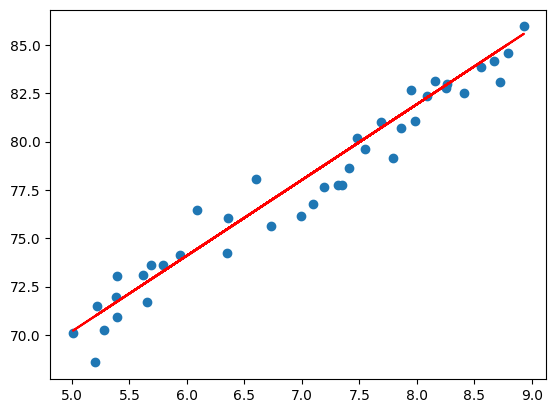

In [53]:
plt.scatter(x_test, y_test)
plt.plot(x_test, lr.predict(x_test.to_frame()), color = "r")